In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
points=np.array([18,19,14,14,11,20,28,30,31,35,33,25,25,27,29,30,19,23],dtype=float)
assists=np.array([3,4,5,4,7,8,7,6,9,12,14,9,4,3,4,12,15,11],dtype=float)
rebounds=np.array([15,14,10,8,14,13,9,5,4,11,6,5,3,8,12,7,6,5],dtype=int)

In [16]:
data=np.array([points,assists,rebounds]).T
df=pd.DataFrame(data,columns=['points','assists','rebounds'])
df


,points,assists,rebounds
0,18.0,3.0,15.0
1,19.0,4.0,14.0
2,14.0,5.0,10.0
3,14.0,4.0,8.0
4,11.0,7.0,14.0
5,20.0,8.0,13.0
6,28.0,7.0,9.0
7,30.0,6.0,5.0
8,31.0,9.0,4.0
9,35.0,12.0,11.0


In [17]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def manhattan(a, b):
    return np.sum(np.abs(a - b))


def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [18]:
def kmeans(data, k, distance='euclidean', max_iter=100):

    # Initial centroids = first k data points
    centroids = data[:k].copy()

    for iteration in range(max_iter):

        clusters = []

        # Assign every point to nearest centroid
        for point in data:

            distances = []

            for centroid in centroids:

                if distance == 'euclidean':
                    d = euclidean(point, centroid)

                elif distance == 'manhattan':
                    d = manhattan(point, centroid)

                elif distance == 'minkowski':
                    d = minkowski(point, centroid)

                distances.append(d)

            clusters.append(np.argmin(distances))

        clusters = np.array(clusters)

        # Calculate new centroids
        new_centroids = []

        for i in range(k):

            points_in_cluster = data[clusters == i]

            if len(points_in_cluster) > 0:
                new_centroids.append(
                    np.mean(points_in_cluster, axis=0)
                )
            else:
                new_centroids.append(centroids[i])

        new_centroids = np.array(new_centroids)

        # Stop if centroids don't change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids, iteration + 1

In [19]:
def calculate_sse(data, clusters, centroids):

    sse = []

    for i in range(len(data)):

        distance_squared = np.sum(
            (data[i] - centroids[clusters[i]]) ** 2
        )

        sse.append(distance_squared)

    return np.array(sse)

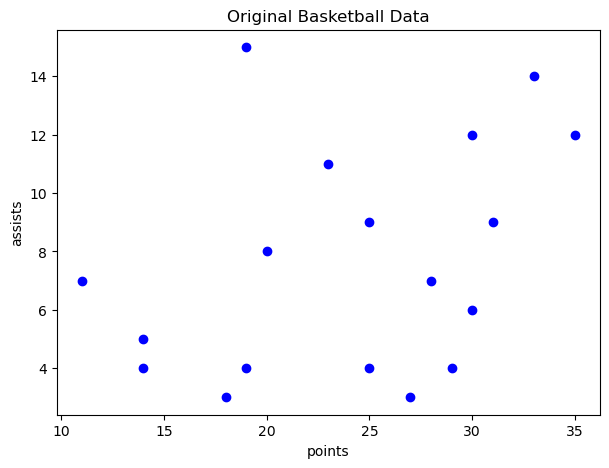

In [21]:

plt.figure(figsize=(7,5))

plt.scatter(
    df['points'],
    df['assists'],
    color='blue'
)

plt.xlabel("points")
plt.ylabel("assists")
plt.title("Original Basketball Data")

plt.show()


K = 1
Iterations = 2
Total SSE = 1347.5


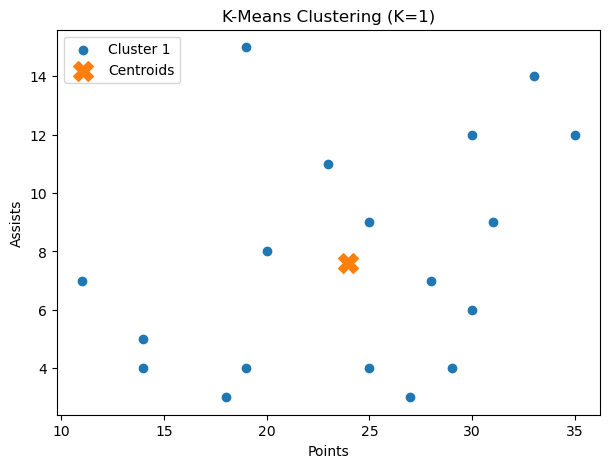


K = 2
Iterations = 3
Total SSE = 601.0


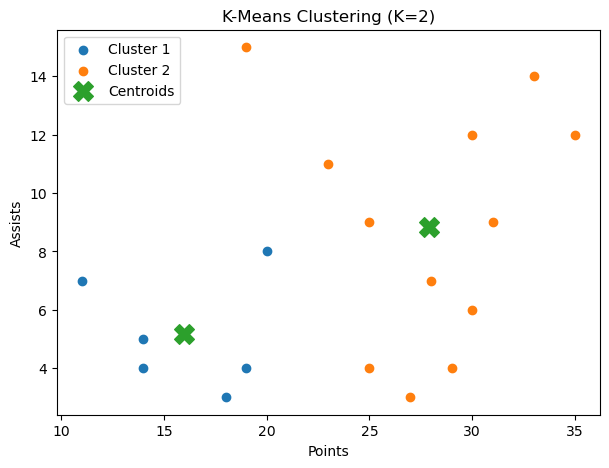


K = 3
Iterations = 3
Total SSE = 514.75


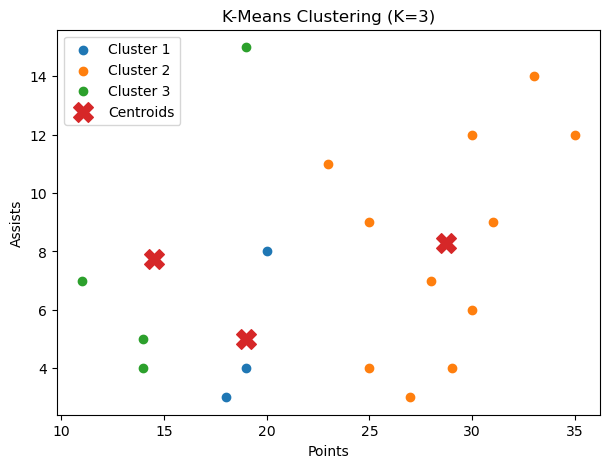


K = 4
Iterations = 5
Total SSE = 356.0833333333333


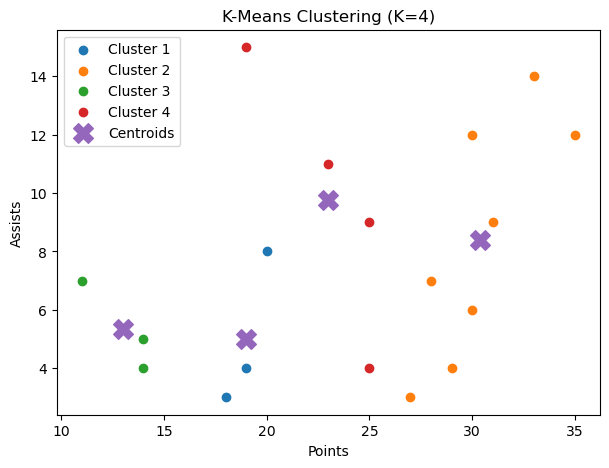

In [23]:
all_sse = []

for k in range(1, 5):

    clusters, centroids, iterations = kmeans(
        data,
        k,
        distance='euclidean'
    )

    sse = calculate_sse(
        data,
        clusters,
        centroids
    )

    total_sse = np.sum(sse)

    all_sse.append(total_sse)

    print("\nK =", k)
    print("Iterations =", iterations)
    print("Total SSE =", total_sse)

    # Plot clusters
    plt.figure(figsize=(7,5))

    for i in range(k):

        cluster_points = df[clusters == i]

        plt.scatter(
            cluster_points['points'],
            cluster_points['assists'],
            label=f'Cluster {i+1}'
        )

    # Plot centroids
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='X',
        s=200,
        label='Centroids'
    )

    plt.xlabel("Points")
    plt.ylabel("Assists")
    plt.title(f"K-Means Clustering (K={k})")
    plt.legend()
    plt.show()

In [24]:
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'Total SSE': all_sse
})

print("\nSSE TABLE")
print(sse_table)


SSE TABLE
   K    Total SSE
0  1  1347.500000
1  2   601.000000
2  3   514.750000
3  4   356.083333



SSE Reduction:
K=1 -> K=2: 55.40%
K=2 -> K=3: 14.35%
K=3 -> K=4: 30.82%

Optimal K using Elbow Method = 2


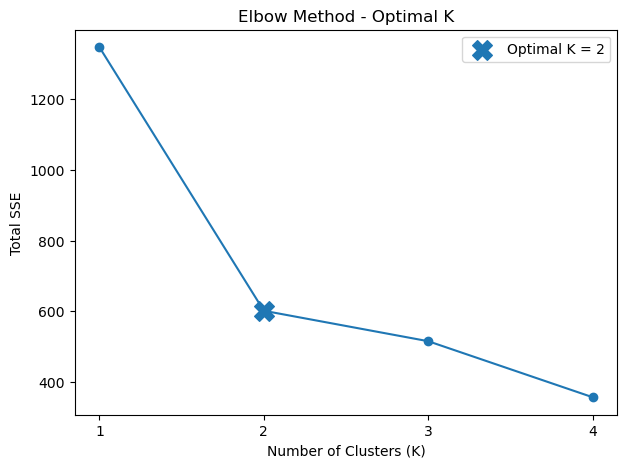

In [26]:
reductions = []

for i in range(1, len(all_sse)):
    reduction = (
        (all_sse[i-1] - all_sse[i])
        / all_sse[i-1]
    ) * 100

    reductions.append(reduction)

print("\nSSE Reduction:")
for i, r in enumerate(reductions):
    print(f"K={i+1} -> K={i+2}: {r:.2f}%")

# Simple elbow selection
optimal_k = 2

print("\nOptimal K using Elbow Method =", optimal_k)


# Plot elbow with optimal K marked
plt.figure(figsize=(7,5))

plt.plot(
    range(1,5),
    all_sse,
    marker='o'
)

plt.scatter(
    optimal_k,
    all_sse[optimal_k-1],
    s=200,
    marker='X',
    label=f'Optimal K = {optimal_k}'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Total SSE")
plt.title("Elbow Method - Optimal K")
plt.xticks(range(1,5))
plt.legend()

plt.show()

Q2



K = 1
Iterations = 2
Total SSE = 1347.5


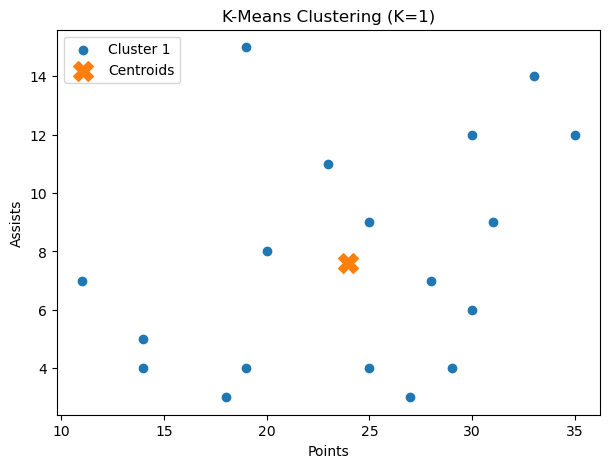


K = 2
Iterations = 3
Total SSE = 601.0


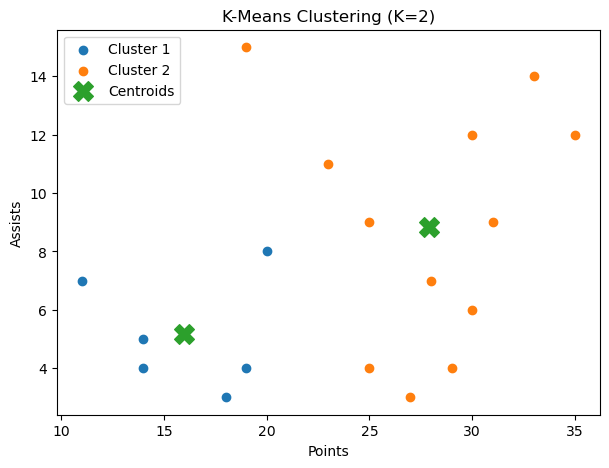


K = 3
Iterations = 3
Total SSE = 530.1666666666666


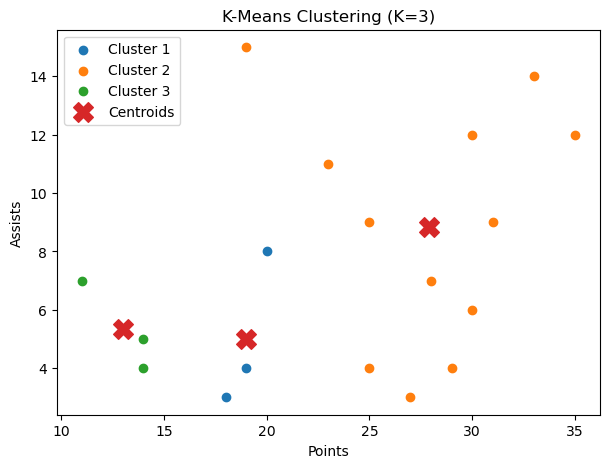


K = 4
Iterations = 5
Total SSE = 405.6190476190476


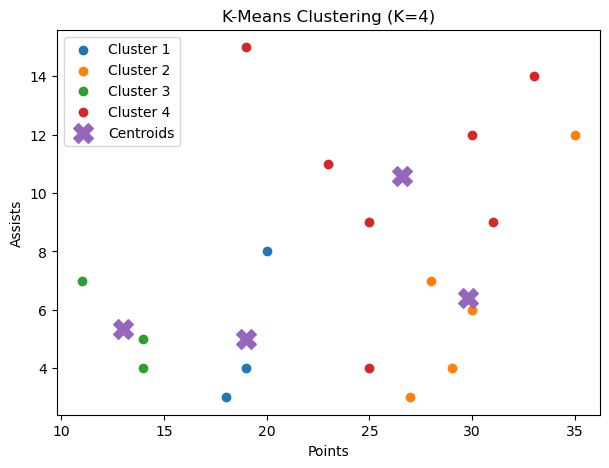

In [27]:
all_sse = []

for k in range(1, 5):

    clusters, centroids, iterations = kmeans(
        data,
        k,
        distance='manhattan'
    )

    sse = calculate_sse(
        data,
        clusters,
        centroids
    )

    total_sse = np.sum(sse)

    all_sse.append(total_sse)

    print("\nK =", k)
    print("Iterations =", iterations)
    print("Total SSE =", total_sse)

    # Plot clusters
    plt.figure(figsize=(7,5))

    for i in range(k):

        cluster_points = df[clusters == i]

        plt.scatter(
            cluster_points['points'],
            cluster_points['assists'],
            label=f'Cluster {i+1}'
        )

    # Plot centroids
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='X',
        s=200,
        label='Centroids'
    )

    plt.xlabel("Points")
    plt.ylabel("Assists")
    plt.title(f"K-Means Clustering (K={k})")
    plt.legend()
    plt.show()

In [28]:
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'Total SSE': all_sse
})

print("\nSSE TABLE")
print(sse_table)


SSE TABLE
   K    Total SSE
0  1  1347.500000
1  2   601.000000
2  3   530.166667
3  4   405.619048



SSE Reduction:
K=1 -> K=2: 55.40%
K=2 -> K=3: 11.79%
K=3 -> K=4: 23.49%

Optimal K using Elbow Method = 2


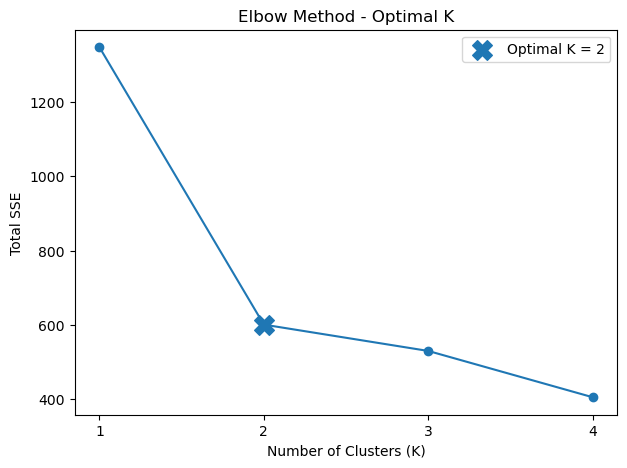

In [29]:
reductions = []

for i in range(1, len(all_sse)):
    reduction = (
        (all_sse[i-1] - all_sse[i])
        / all_sse[i-1]
    ) * 100

    reductions.append(reduction)

print("\nSSE Reduction:")
for i, r in enumerate(reductions):
    print(f"K={i+1} -> K={i+2}: {r:.2f}%")

# Simple elbow selection
optimal_k = 2

print("\nOptimal K using Elbow Method =", optimal_k)


# Plot elbow with optimal K marked
plt.figure(figsize=(7,5))

plt.plot(
    range(1,5),
    all_sse,
    marker='o'
)

plt.scatter(
    optimal_k,
    all_sse[optimal_k-1],
    s=200,
    marker='X',
    label=f'Optimal K = {optimal_k}'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Total SSE")
plt.title("Elbow Method - Optimal K")
plt.xticks(range(1,5))
plt.legend()

plt.show()

Q3


K = 1
Iterations = 2
Total SSE = 1347.5


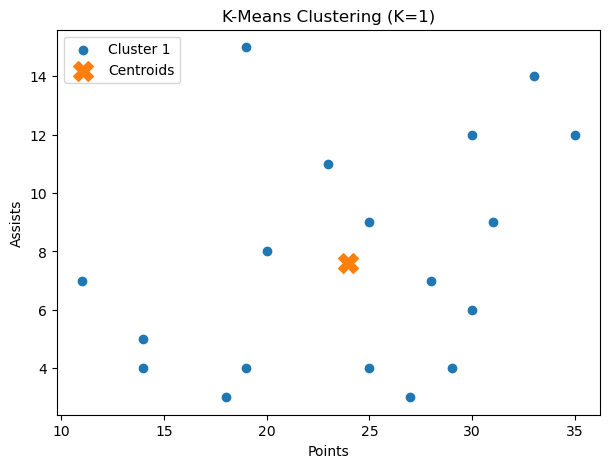


K = 2
Iterations = 3
Total SSE = 601.0


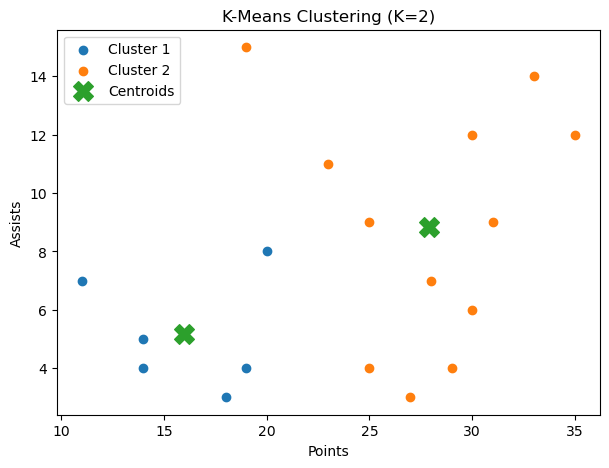


K = 3
Iterations = 4
Total SSE = 514.75


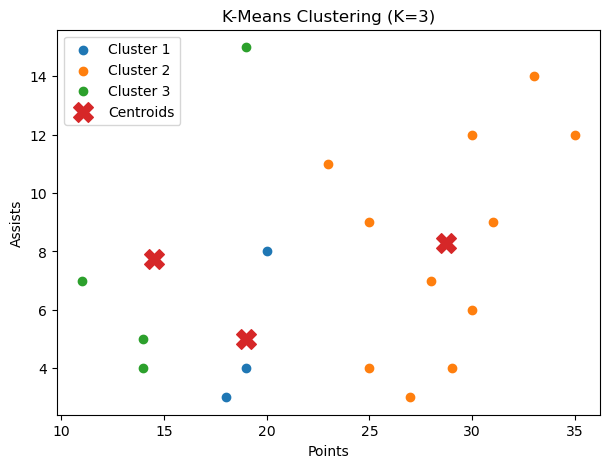


K = 4
Iterations = 5
Total SSE = 436.63888888888886


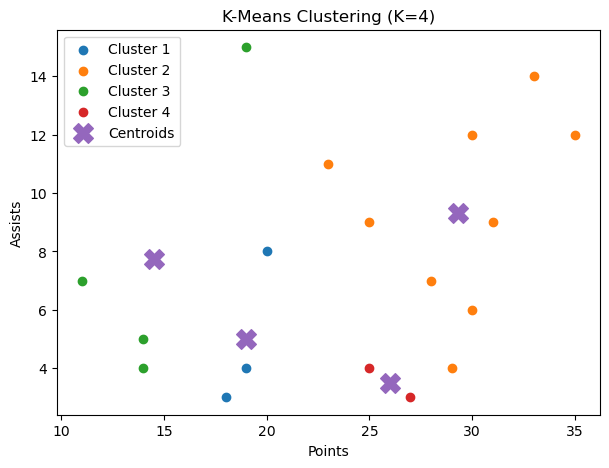

In [30]:
all_sse = []

for k in range(1, 5):

    clusters, centroids, iterations = kmeans(
        data,
        k,
        distance='minkowski'
    )

    sse = calculate_sse(
        data,
        clusters,
        centroids
    )

    total_sse = np.sum(sse)

    all_sse.append(total_sse)

    print("\nK =", k)
    print("Iterations =", iterations)
    print("Total SSE =", total_sse)

    # Plot clusters
    plt.figure(figsize=(7,5))

    for i in range(k):

        cluster_points = df[clusters == i]

        plt.scatter(
            cluster_points['points'],
            cluster_points['assists'],
            label=f'Cluster {i+1}'
        )

    # Plot centroids
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='X',
        s=200,
        label='Centroids'
    )

    plt.xlabel("Points")
    plt.ylabel("Assists")
    plt.title(f"K-Means Clustering (K={k})")
    plt.legend()
    plt.show()

In [31]:
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'Total SSE': all_sse
})

print("\nSSE TABLE")
print(sse_table)


SSE TABLE
   K    Total SSE
0  1  1347.500000
1  2   601.000000
2  3   514.750000
3  4   436.638889



SSE Reduction:
K=1 -> K=2: 55.40%
K=2 -> K=3: 14.35%
K=3 -> K=4: 15.17%

Optimal K using Elbow Method = 2


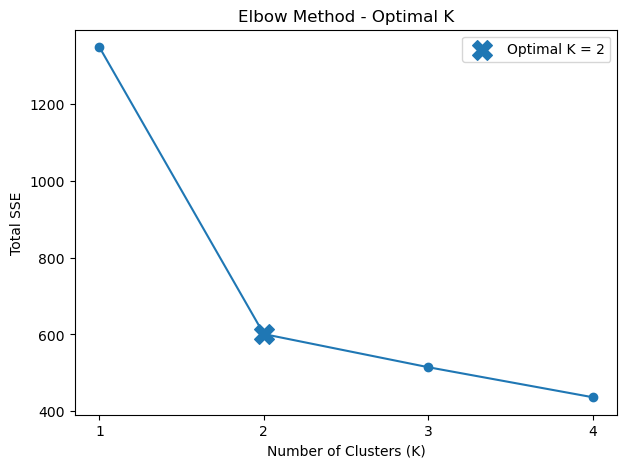

In [32]:
reductions = []

for i in range(1, len(all_sse)):
    reduction = (
        (all_sse[i-1] - all_sse[i])
        / all_sse[i-1]
    ) * 100

    reductions.append(reduction)

print("\nSSE Reduction:")
for i, r in enumerate(reductions):
    print(f"K={i+1} -> K={i+2}: {r:.2f}%")

# Simple elbow selection
optimal_k = 2

print("\nOptimal K using Elbow Method =", optimal_k)


# Plot elbow with optimal K marked
plt.figure(figsize=(7,5))

plt.plot(
    range(1,5),
    all_sse,
    marker='o'
)

plt.scatter(
    optimal_k,
    all_sse[optimal_k-1],
    s=200,
    marker='X',
    label=f'Optimal K = {optimal_k}'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Total SSE")
plt.title("Elbow Method - Optimal K")
plt.xticks(range(1,5))
plt.legend()

plt.show()